In [1]:
"""
v5_streaming_async.py
----------------------
A LangGraph pipeline that reads a free-format MT599 SWIFT settlement message
(which may contain one or more distinct instructions -- cancellations,
creations, amendments -- mixed together in plain text) and produces ONE
structured JSON output: a list of instructions, each tagged with its type
and validated against type-specific required fields.

This file is self-contained: schema, LLM setup, prompt, graph nodes, graph
build, visualization, and two test demonstrations. It does not depend on
any other file.

Pipeline, in plain English (unchanged from the previous version):

    1. EXTRACT       -- one LLM call reads the whole message and returns
                        EVERY instruction found in it. RetryPolicy handles
                        TRANSIENT failures (auto-retry with backoff); a
                        manual fallback handles DETERMINISTIC failures
                        (switches extraction strategy instead of retrying
                        the same failing call).

    2. DISPATCH (Send) -- a routing function returns a LIST of Send(...)
                        objects, one per instruction, so LangGraph runs
                        validation for every instruction IN PARALLEL, in
                        one "superstep."

    3. VALIDATE       -- each parallel branch checks required fields with
                        plain Python. Results merge into one list via a
                        REDUCER (Annotated[..., operator.add]).

    4. HUMAN REVIEW   -- once every parallel branch has finished, any
                        instruction still missing a required field pauses
                        the graph (interrupt()) so a human can supply a
                        value the message never contained in the first
                        place. Skipped entirely if nothing is missing.

    5. FINALIZE       -- assembles the final {"instructions": [...]} JSON.

WHAT'S NEW IN THIS VERSION:

    - extract_instructions is now `async def`, using `.ainvoke()` for every
      LLM call instead of `.invoke()`. This is what makes genuine
      concurrency possible in Demo B below -- a sync function blocking on
      network I/O would tie up a whole thread per call; an async function
      awaiting I/O lets many calls be in flight on a single thread at once.

    - Because a node in this graph is now async, the graph must be driven
      with `.ainvoke()` / `.astream()` -- the sync `.invoke()` / `.stream()`
      methods cannot execute a coroutine without an event loop.

    - Two demonstrations at the bottom:
        Demo A: STREAMING -- watch each parallel validation branch and the
                 human-review pause happen step-by-step, instead of only
                 seeing the final result.
        Demo B: ASYNC CONCURRENCY -- process three different messages at
                 the same time with asyncio.gather(), timed against running
                 them one after another, so the benefit is measured.
"""

import os
import json
import uuid
import time
import asyncio
import operator
from enum import Enum
from typing import Optional, List, Dict, Annotated, TypedDict

from pydantic import BaseModel, Field, ValidationError
from langchain_together import ChatTogether
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command, Send, RetryPolicy


# ---------------------------------------------------------------------------
# 1. STRUCTURED OUTPUT SCHEMA
# ---------------------------------------------------------------------------

class InstructionType(str, Enum):
    cancel = "cancel"
    create = "create"
    amend = "amend"
    unidentified = "unidentified"  # used when no operation could be found


class Instruction(BaseModel):
    """
    One settlement instruction extracted from the message. All non-type
    fields stay Optional[str] -- MT599 is free text, formats vary, and the
    receiving settlement system owns format validation, not us.
    """
    type: InstructionType = Field(
        description="The operation identified from the message text."
    )
    clientRef: Optional[str] = Field(
        default=None, description="Client reference for this instruction."
    )
    scRef: Optional[str] = Field(
        default=None, description="SC (settlement/system) reference, if present."
    )
    isin: Optional[str] = Field(
        default=None, description="ISIN of the security, if present."
    )
    qty: Optional[str] = Field(
        default=None, description="Quantity, captured exactly as written."
    )
    settlementDate: Optional[str] = Field(
        default=None, description="Settlement date, captured exactly as written."
    )
    sfkAccount: Optional[str] = Field(
        default=None, description="SFK account number, if present."
    )
    pset: Optional[str] = Field(
        default=None, description="Place of settlement, if present."
    )
    party: Optional[str] = Field(
        default=None, description="Party details, if present."
    )
    cpty: Optional[str] = Field(
        default=None, description="Counterparty details, if present."
    )
    remarks: Optional[str] = Field(
        default=None,
        description=(
            "Free-text notes explaining any problem with this instruction. "
            "Populated when type is 'unidentified', or when a required "
            "field is missing. Cleared if a human later supplies the "
            "missing value during review."
        ),
    )


class ExtractionResult(BaseModel):
    """
    Top-level shape returned by this pipeline. ALWAYS a list, ALWAYS
    non-empty -- one contract regardless of how many instructions (or none
    identifiable) the message contained.
    """
    instructions: List[Instruction] = Field(
        description=(
            "One or more instructions found in the message. If nothing "
            "could be identified, return exactly one instruction with "
            "type='unidentified' and an explanation in remarks."
        )
    )


C:\Users\Pandiyan\anaconda3\envs\langchain\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dotenv import load_dotenv
load_dotenv(".env")
# ---------------------------------------------------------------------------
# 2. LLM SETUP (Together AI via LangChain)
# ---------------------------------------------------------------------------

TOGETHER_MODEL = "Qwen/Qwen2.5-7B-Instruct-Turbo"

llm = ChatTogether(
    model=TOGETHER_MODEL,
    temperature=0,
    together_api_key=os.getenv("TOGETHER_API_KEY"),
)

structured_llm_json_schema = llm.with_structured_output(ExtractionResult, method="json_schema")


async def _manual_json_extract(prompt: str) -> ExtractionResult:
    """
    DETERMINISTIC-FAILURE fallback -- async version. Prompts the raw `llm`
    for plain JSON text via `.ainvoke()` (no schema sent to the provider at
    all), then parses and validates the response ourselves.
    """
    manual_prompt = (
        prompt
        + "\n\nRespond with ONLY a single valid JSON object -- no markdown "
        "code fences, no explanation, no text before or after the JSON. "
        'The JSON must have this exact top-level shape: {"instructions": [...]}, '
        "where each item in the list has the fields described above."
    )
    response = await llm.ainvoke(manual_prompt)
    raw_text = response.content.strip()

    if raw_text.startswith("```"):
        raw_text = raw_text.strip("`")
        if raw_text.lower().startswith("json"):
            raw_text = raw_text[4:]
        raw_text = raw_text.strip()

    data = json.loads(raw_text)
    return ExtractionResult.model_validate(data)



In [3]:

# ---------------------------------------------------------------------------
# 3. PROMPT
# ---------------------------------------------------------------------------

EXTRACTION_PROMPT = """You are parsing a free-format MT599 SWIFT message used in trade settlement.

The message may contain ONE OR MORE distinct instructions (cancellation, creation, amendment),
mixed together in free text, in any order.

For EACH instruction you find, extract:
- type: cancel, create, amend, or unidentified
- clientRef, scRef, isin, qty, settlementDate, sfkAccount, pset, party, cpty
- remarks: only used to explain when type is "unidentified"

Rules:
1. Capture every field exactly as written in the message. Do NOT reformat dates,
   numbers, or reference codes.
2. If a field is not mentioned for an instruction, leave it null. Do not guess.
3. If you cannot identify ANY operation in the entire message, return exactly ONE
   instruction with type="unidentified" and a short explanation in remarks.
4. Return every instruction you find -- do not drop or merge separate instructions.

Message:
\"\"\"{message}\"\"\"
"""


In [4]:

# ---------------------------------------------------------------------------
# 4. REQUIRED FIELDS PER TYPE
# ---------------------------------------------------------------------------

REQUIRED_FIELDS_BY_TYPE: Dict[InstructionType, List[str]] = {
    InstructionType.cancel: ["clientRef"],
    InstructionType.create: ["clientRef", "isin", "qty", "sfkAccount"],
    InstructionType.amend: ["clientRef"],
    InstructionType.unidentified: [],
}


def _missing_fields(instruction: Instruction, required: List[str]) -> List[str]:
    missing = []
    for field_name in required:
        value = getattr(instruction, field_name)
        if value is None or str(value).strip() == "":
            missing.append(field_name)
    return missing


def _append_missing_note(instruction: Instruction, missing: List[str]) -> Instruction:
    if not missing:
        return instruction
    note = f"Missing required fields: {', '.join(missing)}"
    instruction.remarks = f"{instruction.remarks}; {note}" if instruction.remarks else note
    return instruction



In [5]:

# ---------------------------------------------------------------------------
# 5. GRAPH STATE
# ---------------------------------------------------------------------------

class SettlementState(TypedDict):
    raw_message: str

    all_instructions: List[Instruction]

    processed_instructions: Annotated[List[Instruction], operator.add]
    # Reducer required: multiple parallel validate_instruction branches
    # (section 8) each write a single-item list here at the same time.

    result: Optional[ExtractionResult]
    error: Optional[str]


class InstructionValidationState(TypedDict):
    """
    State schema for the parallel validation branch only. Each Send(...)
    hands exactly this shape -- one instruction, nothing else from the
    main SettlementState is visible inside validate_instruction.
    """
    instruction_to_validate: Instruction


In [6]:

# ---------------------------------------------------------------------------
# 6. NODE: extract_instructions (NOW ASYNC)
#    Failure handling still splits into two mechanisms with different jobs:
#      - RetryPolicy (section 10): auto-retries the WHOLE node, with
#        backoff, for TRANSIENT failures only (its default retry_on covers
#        connection errors, timeouts, 5xx -- not schema/validation bugs).
#      - Manual fallback (this function): immediately switches extraction
#        STRATEGY for DETERMINISTIC failures, since retrying an identical
#        call would fail again identically.
# ---------------------------------------------------------------------------

async def extract_instructions(state: SettlementState) -> SettlementState:
    message = state["raw_message"]
    prompt = EXTRACTION_PROMPT.format(message=message)

    try:
        result = await structured_llm_json_schema.ainvoke(prompt)
    except (ValidationError, json.JSONDecodeError) as deterministic_error:
        result = await _fallback_after_deterministic_failure(prompt, deterministic_error)
    except Exception as e:
        # Heuristic classification -- see v4 for the full explanation of
        # why this is a simplification (langchain_together doesn't expose
        # a distinct exception type for a grammar-compile failure).
        if "grammar" in str(e).lower() or "schema" in str(e).lower():
            result = await _fallback_after_deterministic_failure(prompt, e)
        else:
            # Looks transient -- re-raise so RetryPolicy retries the WHOLE
            # node automatically, with backoff.
            raise

    state["all_instructions"] = result.instructions
    state["error"] = None
    return state


async def _fallback_after_deterministic_failure(prompt: str, original_error: Exception) -> ExtractionResult:
    """
    Tries the manual prompt-and-parse strategy once; if that ALSO fails,
    gives up gracefully with a single 'unidentified' placeholder so the
    rest of the graph always has a valid, non-empty list to fan out over.
    """
    try:
        return await _manual_json_extract(prompt)
    except Exception as fallback_error:
        return ExtractionResult(
            instructions=[
                Instruction(
                    type=InstructionType.unidentified,
                    remarks=(
                        f"Extraction failed. Preferred mode error: {original_error}. "
                        f"Fallback mode error: {fallback_error}."
                    ),
                )
            ]
        )



In [7]:

# ---------------------------------------------------------------------------
# 7. NODE: validate_instruction (the Send target)
#    Stays SYNCHRONOUS -- plain Python field checks, no I/O, nothing to
#    gain from async here. LangGraph runs sync and async nodes together in
#    the same graph without any special handling required.
# ---------------------------------------------------------------------------

def validate_instruction(state: InstructionValidationState) -> dict:
    instruction = state["instruction_to_validate"]
    required = REQUIRED_FIELDS_BY_TYPE.get(instruction.type, [])
    missing = _missing_fields(instruction, required)
    instruction = _append_missing_note(instruction, missing)
    return {"processed_instructions": [instruction]}



In [8]:

# ---------------------------------------------------------------------------
# 8. DISPATCH FUNCTION (the Send fan-out)
# ---------------------------------------------------------------------------

def dispatch_to_validation(state: SettlementState) -> List[Send]:
    return [
        Send("validate_instruction", {"instruction_to_validate": instruction})
        for instruction in state["all_instructions"]
    ]


In [9]:

# ---------------------------------------------------------------------------
# 9. NODE: human_review
#    Also stays synchronous -- no I/O until interrupt() pauses the graph,
#    and interrupt()/Command work identically whether the surrounding
#    graph is driven with invoke/stream or ainvoke/astream.
# ---------------------------------------------------------------------------

def human_review(state: SettlementState) -> SettlementState:
    incomplete = []
    for index, instruction in enumerate(state["processed_instructions"]):
        required = REQUIRED_FIELDS_BY_TYPE.get(instruction.type, [])
        missing = _missing_fields(instruction, required)
        if missing:
            incomplete.append({
                "index": index,
                "clientRef": instruction.clientRef,
                "type": instruction.type.value,
                "missing_fields": missing,
            })

    if not incomplete:
        return state

    human_updates = interrupt({
        "message": (
            "The following instructions are missing required fields that "
            "were NOT present in the original MT599 message text. Supply "
            "values only if known from another source -- otherwise leave "
            "unresolved."
        ),
        "items": incomplete,
    })

    if human_updates:
        for index_str, field_updates in human_updates.items():
            instruction = state["processed_instructions"][int(index_str)]
            for field_name, value in field_updates.items():
                setattr(instruction, field_name, value)

    for item in incomplete:
        instruction = state["processed_instructions"][item["index"]]
        required = REQUIRED_FIELDS_BY_TYPE.get(instruction.type, [])
        still_missing = _missing_fields(instruction, required)
        instruction.remarks = (
            f"Missing required fields: {', '.join(still_missing)}"
            if still_missing else None
        )

    return state


In [10]:

# ---------------------------------------------------------------------------
# 10. NODE: finalize
# ---------------------------------------------------------------------------

def finalize(state: SettlementState) -> SettlementState:
    state["result"] = ExtractionResult(instructions=state["processed_instructions"])
    return state


In [11]:

# ---------------------------------------------------------------------------
# 11. BUILD THE GRAPH
#     Same shape as the previous version -- streaming/async are properties
#     of HOW you call the graph, not how you build it. No structural
#     changes needed here versus a fully-synchronous graph.
# ---------------------------------------------------------------------------

builder = StateGraph(SettlementState)

builder.add_node(
    "extract_instructions",
    extract_instructions,
    retry_policy=RetryPolicy(
        max_attempts=3,
        initial_interval=0.5,
        backoff_factor=2.0,
    ),
)
builder.add_node("validate_instruction", validate_instruction)
builder.add_node("human_review", human_review)
builder.add_node("finalize", finalize)

builder.set_entry_point("extract_instructions")
builder.add_conditional_edges("extract_instructions", dispatch_to_validation, ["validate_instruction"])
builder.add_edge("validate_instruction", "human_review")
builder.add_edge("human_review", "finalize")
builder.set_finish_point("finalize")

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)



In [12]:

# ---------------------------------------------------------------------------
# 12. VISUALIZE THE GRAPH
# ---------------------------------------------------------------------------

def visualize_graph(compiled_graph, output_path: str = "graph_v5.png") -> None:
    try:
        png_bytes = compiled_graph.get_graph().draw_mermaid_png()
    except Exception as e:
        print(f"Graph visualization failed (mermaid/graphviz dependency issue?): {e}")
        return

    try:
        from IPython.display import Image, display
        from IPython import get_ipython
        if get_ipython() is not None:
            display(Image(png_bytes))
            return
    except ImportError:
        pass

    with open(output_path, "wb") as f:
        f.write(png_bytes)
    print(f"Graph diagram saved to: {output_path}")


In [13]:

# ---------------------------------------------------------------------------
# 13. DEMO A -- STREAMING
#     Uses graph.astream(..., stream_mode="updates") instead of ainvoke().
#     "updates" mode yields only the CHANGED keys after each node finishes
#     -- so with 3 parallel validate_instruction branches, you should see
#     THREE separate small updates come through (one per branch), rather
#     than a single combined result at the end. This is the most direct
#     way to actually SEE the Send-based parallelism from v4 happening,
#     rather than just trusting it happened.
# ---------------------------------------------------------------------------

async def demo_streaming():
    print("\n" + "=" * 70)
    print("DEMO A: STREAMING (stream_mode='updates')")
    print("=" * 70)

    sample_message = (
        "Please cancel the trade has client reference XYZABC, "
        "Also create a new trade with client reference QWERTY, "
        "it should have the ISIN DFGHISIN, Qty=100. "
        "Also amend trade with client reference AMEND001, change settlement date to 5th July."
    )

    config = {"configurable": {"thread_id": str(uuid.uuid4())}}
    initial_state = {
        "raw_message": sample_message,
        "all_instructions": [],
        "processed_instructions": [],
        "result": None,
        "error": None,
    }

    interrupt_payload = None
    async for chunk in graph.astream(initial_state, config, stream_mode="updates"):
        # `chunk` looks like {"node_name": {partial state update}}
        for node_name, update in chunk.items():
            if node_name == "__interrupt__":
                interrupt_payload = update[0].value
                print(f"\n[PAUSED] interrupt() fired: {interrupt_payload['message']}")
            else:
                print(f"\n[node finished] {node_name}")
                print(json.dumps(
                    {k: (v.model_dump() if hasattr(v, "model_dump") else v) for k, v in update.items()},
                    indent=2, default=str,
                ))

    if interrupt_payload:
        human_supplied_updates: dict = {}
        for item in interrupt_payload["items"]:
            index = str(item["index"])
            print(
                f"\nInstruction #{item['index']} "
                f"(type={item['type']}, clientRef={item['clientRef']}) "
                f"is missing: {', '.join(item['missing_fields'])}"
            )
            field_updates = {}
            for field_name in item["missing_fields"]:
                value = input(f"  Enter value for '{field_name}' (or press Enter to skip): ").strip()
                if value:
                    field_updates[field_name] = value
            if field_updates:
                human_supplied_updates[index] = field_updates

        print("\n[resuming after human review]")
        final_state = None
        async for chunk in graph.astream(Command(resume=human_supplied_updates), config, stream_mode="updates"):
            for node_name, update in chunk.items():
                print(f"\n[node finished] {node_name}")
            final_state = chunk

        # Fetch the final committed state after resuming.
        state_snapshot = await graph.aget_state(config)
        result = state_snapshot.values["result"]
    else:
        state_snapshot = await graph.aget_state(config)
        result = state_snapshot.values["result"]

    print("\n--- Demo A final result ---")
    print(json.dumps(result.model_dump(), indent=2))


In [14]:

# ---------------------------------------------------------------------------
# 14. DEMO B -- ASYNC CONCURRENCY
#     Runs THREE different, complete MT599 messages through the graph AT
#     THE SAME TIME with asyncio.gather(), each on its OWN thread_id (they
#     are independent runs, not one graph fanning out -- this models a bank
#     receiving many incoming messages and processing them concurrently
#     rather than one at a time). Timed against a sequential run so the
#     benefit is measured, not just asserted.
# ---------------------------------------------------------------------------

MESSAGES_FOR_CONCURRENCY_DEMO = [
    "Please cancel the trade with client reference AAA111.",
    "Create a new trade with client reference BBB222, ISIN US0378331005, Qty=50, SFK Account=1111.",
    "Amend trade with client reference CCC333, change settlement date to 10th July.",
]


async def _run_one(message: str, thread_id: str) -> ExtractionResult:
    config = {"configurable": {"thread_id": thread_id}}
    initial_state = {
        "raw_message": message,
        "all_instructions": [],
        "processed_instructions": [],
        "result": None,
        "error": None,
    }
    final_state = await graph.ainvoke(initial_state, config)
    return final_state["result"]


async def demo_async_concurrency():
    print("\n" + "=" * 70)
    print("DEMO B: ASYNC CONCURRENCY (asyncio.gather vs sequential)")
    print("=" * 70)

    # Sequential baseline: one message fully finishes before the next starts.
    start = time.perf_counter()
    for i, message in enumerate(MESSAGES_FOR_CONCURRENCY_DEMO):
        await _run_one(message, thread_id=f"seq-{uuid.uuid4()}")
    sequential_seconds = time.perf_counter() - start

    # Concurrent: all three in flight at once via asyncio.gather.
    start = time.perf_counter()
    results = await asyncio.gather(*[
        _run_one(message, thread_id=f"concurrent-{uuid.uuid4()}")
        for message in MESSAGES_FOR_CONCURRENCY_DEMO
    ])
    concurrent_seconds = time.perf_counter() - start

    print(f"\nSequential total: {sequential_seconds:.2f}s")
    print(f"Concurrent total:  {concurrent_seconds:.2f}s")

    for message, result in zip(MESSAGES_FOR_CONCURRENCY_DEMO, results):
        print(f"\nMessage: {message}")
        print(json.dumps(result.model_dump(), indent=2))


In [17]:
# ---------------------------------------------------------------------------
# 15. RUN BOTH DEMOS
# ---------------------------------------------------------------------------

async def main():
    visualize_graph(graph)
    await demo_streaming()
    await demo_async_concurrency()


if __name__ == "__main__":
    try:
        asyncio.get_running_loop()
        # A loop is ALREADY running -- this is the Jupyter/IPython case.
        # asyncio.run() always fails here because it tries to start a
        # SECOND event loop, and Python only allows one per thread.
        # Jupyter supports top-level `await` directly in a cell, so that's
        # the correct way to run this there instead of asyncio.run().
        print(
            "A running event loop was detected (this is normal inside "
            "Jupyter/IPython).\n"
            "asyncio.run() cannot start a second loop on top of it.\n\n"
            "Instead, run this directly in a notebook cell:\n\n"
            "    await main()\n"
        )
    except RuntimeError:
        # No loop running -- this is the plain `python v5_streaming_async.py`
        # case. asyncio.run() is the correct, normal way to start one here.
        asyncio.run(main())


A running event loop was detected (this is normal inside Jupyter/IPython).
asyncio.run() cannot start a second loop on top of it.

Instead, run this directly in a notebook cell:

    await main()



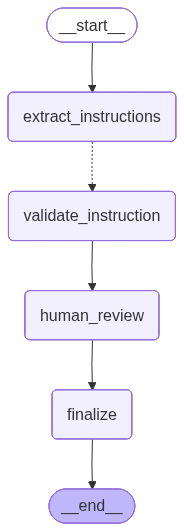


DEMO A: STREAMING (stream_mode='updates')

[node finished] extract_instructions
{
  "raw_message": "Please cancel the trade has client reference XYZABC, Also create a new trade with client reference QWERTY, it should have the ISIN DFGHISIN, Qty=100. Also amend trade with client reference AMEND001, change settlement date to 5th July.",
  "all_instructions": [
    "type=<InstructionType.cancel: 'cancel'> clientRef='XYZABC' scRef=None isin=None qty=None settlementDate=None sfkAccount=None pset=None party=None cpty=None remarks=None",
    "type=<InstructionType.create: 'create'> clientRef='QWERTY' scRef=None isin='DFGHISIN' qty='100' settlementDate=None sfkAccount=None pset=None party=None cpty=None remarks=None",
    "type=<InstructionType.amend: 'amend'> clientRef='AMEND001' scRef=None isin=None qty=None settlementDate='5th July' sfkAccount=None pset=None party=None cpty=None remarks=None"
  ],
  "processed_instructions": [],
  "result": null,
  "error": null
}

[node finished] validate

  Enter value for 'sfkAccount' (or press Enter to skip):  897


Deserializing unregistered type __main__.InstructionType from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'InstructionType')]
Deserializing unregistered type __main__.Instruction from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Instruction')]
Deserializing unregistered type __main__.ExtractionResult from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ExtractionResult')]



[resuming after human review]

[node finished] human_review

[node finished] finalize

--- Demo A final result ---
{
  "instructions": [
    {
      "type": "cancel",
      "clientRef": "XYZABC",
      "scRef": null,
      "isin": null,
      "qty": null,
      "settlementDate": null,
      "sfkAccount": null,
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    },
    {
      "type": "create",
      "clientRef": "QWERTY",
      "scRef": null,
      "isin": "DFGHISIN",
      "qty": "100",
      "settlementDate": null,
      "sfkAccount": "897",
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    },
    {
      "type": "amend",
      "clientRef": "AMEND001",
      "scRef": null,
      "isin": null,
      "qty": null,
      "settlementDate": "5th July",
      "sfkAccount": null,
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    },
    {
      "type": "cancel",
      "clientRef": "XY

In [19]:
await main()